## 2.1 计算题

1. **向量点积** a · b = 8

2. **矩阵乘法** A × B 结果形状 2×2，矩阵:
\[
\begin{bmatrix}
8 & 5 \\
1 & -2
\end{bmatrix}
\]

3. **向量a的Frobenius范数** = √14

In [1]:
# 2.2 编程题：矩阵运算
import numpy as np

# 1. 创建 3×4 标准正态分布随机矩阵 X
X = np.random.randn(3, 4)
print("1. 3×4 标准正态分布随机矩阵 X:")
print(X)

# 2. 创建 4×2 均匀分布随机矩阵 W
W = np.random.uniform(0, 1, size=(4, 2))
print("\n2. 4×2 均匀分布随机矩阵 W:")
print(W)

# 3. 计算矩阵乘积 Z = X × W
Z = np.dot(X, W)
print("\n3. 矩阵乘积 Z = X × W:")
print(Z)

# 4. 计算 Z 的转置 ZT
ZT = Z.T
print("\n4. Z 的转置 ZT:")
print(ZT)

# 5. 计算 Z 的 Frobenius 范数
fro_norm_Z = np.linalg.norm(Z, 'fro')
print("\n5. Z的Frobenius范数:", fro_norm_Z)

1. 3×4 标准正态分布随机矩阵 X:
[[-0.02264246 -0.20229562  0.40205811  1.27977652]
 [-0.2493299  -0.67649059 -0.80650454 -0.8307512 ]
 [-0.45622838  0.50292511  0.89440753 -0.51939263]]

2. 4×2 均匀分布随机矩阵 W:
[[0.0416173  0.17451719]
 [0.48692792 0.99470119]
 [0.47376288 0.42124753]
 [0.30709063 0.49449575]]

3. 矩阵乘积 Z = X × W:
[[ 0.48404189  0.59703485]
 [-0.97698642 -1.46695934]
 [ 0.49013776  0.54057002]]

4. Z 的转置 ZT:
[[ 0.48404189 -0.97698642  0.49013776]
 [ 0.59703485 -1.46695934  0.54057002]]

5. Z的Frobenius范数: 2.056616224036322


## 3.1 计算题 - 贝叶斯公式应用

已知条件（疾病检测问题）：
- 先验概率 P(患病) = 0.001
- 先验概率 P(未患病) = 0.999
- 真阳性率 P(阳性|患病) = 0.99
- 假阳性率 P(阳性|未患病) = 0.02

根据贝叶斯公式：
\[
P(患病|阳性) = \frac{P(阳性|患病) \cdot P(患病)}{P(阳性|患病) \cdot P(患病) + P(阳性|未患病) \cdot P(未患病)}
\]

代入数值计算：
\[
P(患病|阳性) = \frac{0.99 \times 0.001}{0.99 \times 0.001 + 0.02 \times 0.999} = \frac{0.00099}{0.02097} \approx 4.72\%
\]

**结论**：检测阳性时真正患病概率约为 4.72%

c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Prog

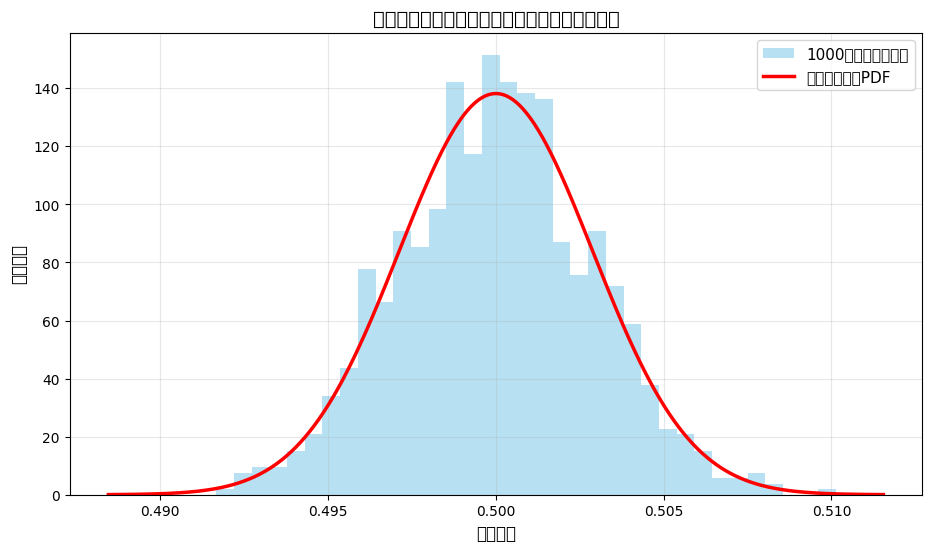

均值序列的实际方差： 0.0000083303
均值序列的理论方差(1/(12*n))： 0.0000083333


In [2]:
# 3.2 编程题：中心极限定理模拟
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------- 1. 生成数据，模拟中心极限定理 ----------------------
n = 10000   # 每组均匀分布样本数量
m = 1000    # 重复实验次数

# 一次性生成 m×n 个U(0,1)均匀分布随机数（向量化运算，效率远高于循环）
random_data = np.random.uniform(low=0, high=1, size=(m, n))
# 对每一组n个数据求均值，得到1000个均值
sample_means = random_data.mean(axis=1)

# ---------------------- 2. 绘制直方图 + 叠加理论正态分布曲线 ----------------------
# 原始均匀分布U(0,1)的理论参数
pop_mean = 0.5
pop_var = 1 / 12

# 样本均值的理论正态分布参数
theory_mean = pop_mean
theory_variance = pop_var / n
theory_std = np.sqrt(theory_variance)

# 画布设置
plt.figure(figsize=(11, 6), dpi=100)

# 绘制1000个均值的归一化直方图（density=True 和PDF尺度对齐）
plt.hist(
    sample_means, 
    bins=35, 
    density=True, 
    alpha=0.6, 
    color='skyblue',
    label='1000次实验均值分布'
)

# 生成理论正态分布概率密度曲线
x_range = np.linspace(theory_mean - 4*theory_std, theory_mean + 4*theory_std, 1000)
normal_pdf = norm.pdf(x_range, loc=theory_mean, scale=theory_std)
plt.plot(x_range, normal_pdf, 'red', linewidth=2.5, label='理论正态分布PDF')

# 图表美化
plt.xlabel("样本均值", fontsize=12)
plt.ylabel("概率密度", fontsize=12)
plt.title("中心极限定理模拟：均匀分布均值趋近正态分布", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

# ---------------------- 3. 计算均值的实际方差 ----------------------
actual_variance = np.var(sample_means, ddof=1)  # 无偏样本方差

# 打印结果对比
print("均值序列的实际方差：", format(actual_variance, '.10f'))
print("均值序列的理论方差(1/(12*n))：", format(theory_variance, '.10f'))

## 4.1 计算题 - 链式法则求偏导

已知函数：z = (2w₁ + w₂ - 3)²

### 偏导数表达式
\[
\frac{\partial z}{\partial w_1} = 4 \cdot (2w_1 + w_2 - 3)
\]
\[
\frac{\partial z}{\partial w_2} = 2 \cdot (2w_1 + w_2 - 3)
\]

### 当 w₁ = 0.5, w₂ = 1 时
先计算内部表达式：
\[
2w_1 + w_2 - 3 = 2 \times 0.5 + 1 - 3 = 1 + 1 - 3 = -1
\]

代入偏导数公式：
\[
\frac{\partial z}{\partial w_1} = 4 \times (-1) = -4
\]
\[
\frac{\partial z}{\partial w_2} = 2 \times (-1) = -2
\]

**梯度** = (-4, -2)

In [3]:
# 4.2 编程题：链式法则与自动微分
# 1. 定义给定输入与权重
x = 2
w1 = 1.5
w2 = 0.5

# 2. 前向传播计算
a = x * w1
b = a + w2
L = b ** 2

print("===== 1. 前向传播结果 =====")
print("a = x * w1 =", a)
print("b = a + w2 =", b)
print("损失 L = b^2 =", L)

# 3. 手动链式法则反向求梯度
dL_db = 2 * b       # L对b的导数
dL_dw2 = dL_db * 1  # 链式求导：dL/db * db/dw2
dL_dw1 = dL_db * 1 * x # 链式求导：dL/db * db/da * da/dw1

print("\n===== 2. 手动链式梯度结果 =====")
print("dL/dw1 =", dL_dw1)
print("dL/dw2 =", dL_dw2)

# 4. 使用PyTorch自动微分验证
import torch

x_tensor = torch.tensor(2.0)
w1_tensor = torch.tensor(1.5, requires_grad=True)
w2_tensor = torch.tensor(0.5, requires_grad=True)

# 复刻前向计算图
a_tensor = x_tensor * w1_tensor
b_tensor = a_tensor + w2_tensor
L_tensor = b_tensor ** 2

# 自动反向传播
L_tensor.backward()

print("\n===== 3. PyTorch自动梯度结果 =====")
print("自动微分 dL/dw1 =", w1_tensor.grad.item())
print("自动微分 dL/dw2 =", w2_tensor.grad.item())

print("\n===== 4. 结果一致性验证 =====")
print("w1梯度是否完全匹配：", dL_dw1 == w1_tensor.grad.item())
print("w2梯度是否完全匹配：", dL_dw2 == w2_tensor.grad.item())

===== 1. 前向传播结果 =====
a = x * w1 = 3.0
b = a + w2 = 3.5
损失 L = b^2 = 12.25

===== 2. 手动链式梯度结果 =====
dL/dw1 = 14.0
dL/dw2 = 7.0

===== 3. PyTorch自动梯度结果 =====
自动微分 dL/dw1 = 14.0
自动微分 dL/dw2 = 7.0

===== 4. 结果一致性验证 =====
w1梯度是否完全匹配： True
w2梯度是否完全匹配： True


## 5.1 计算题 - 线性回归损失函数的梯度

已知均方误差损失函数：
\[
L = \frac{1}{n} \sum_{i=1}^{n} [y_i - (w x_i + b)]^2
\]

### 1. 损失对 w 的偏导数
\[
\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} \left[ 2 \cdot (y_i - w x_i - b) \cdot (-x_i) \right]
\]
\[
= -\frac{2}{n} \sum_{i=1}^{n} \left[ x_i \cdot (y_i - w x_i - b) \right]
\]

### 2. 损失对 b 的偏导数
\[
\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} \left[ 2 \cdot (y_i - w x_i - b) \cdot (-1) \right]
\]
\[
= -\frac{2}{n} \sum_{i=1}^{n} (y_i - w x_i - b)
\]

Epoch [10/50]  平均损失: 0.4677
Epoch [20/50]  平均损失: 0.3072
Epoch [30/50]  平均损失: 0.2459
Epoch [40/50]  平均损失: 0.2126
Epoch [50/50]  平均损失: 0.1901

===== 最终测试结果 =====
测试集准确率: 95.83%


c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29109 (\N{CJK UNIFIED IDEOGRAPH-71B5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Prog

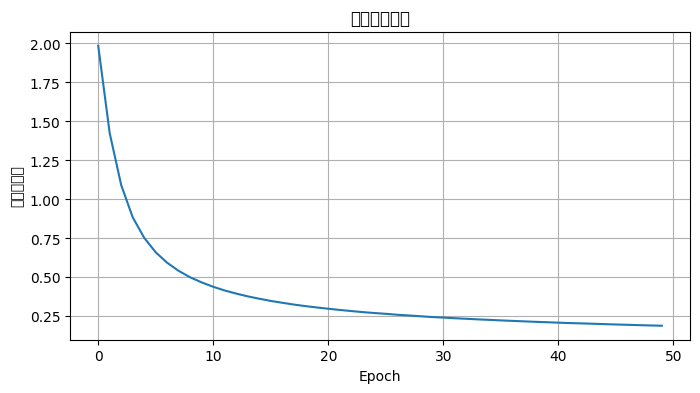

In [4]:
# 5.2 编程题：Softmax回归手写数字分类
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# ===================== 1. 加载并预处理数据集 =====================
digits = load_digits()
X = digits.data / 16.0  # 数据归一化
y = digits.target.reshape(-1, 1)

# 划分训练集测试集 + One-Hot编码
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

# ===================== 2. 定义核心函数 =====================
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    epsilon = 1e-8
    return -np.mean(np.sum(y_true * np.log(y_pred + epsilon), axis=1))

def predict(X, W, b):
    z = np.dot(X, W) + b
    return softmax(z)

# ===================== 3. 超参数与初始化 =====================
input_dim = 64
output_dim = 10
lr = 0.1
batch_size = 32
epochs = 50

np.random.seed(42)
W = np.random.randn(input_dim, output_dim) * 0.01
b = np.zeros((1, output_dim))
loss_history = []

# ===================== 4. 小批量SGD训练 =====================
for epoch in range(epochs):
    shuffle_idx = np.random.permutation(len(X_train))
    X_shuffle = X_train[shuffle_idx]
    y_shuffle = y_train_onehot[shuffle_idx]
    epoch_loss = 0
    
    for i in range(0, len(X_train), batch_size):
        X_batch = X_shuffle[i:i+batch_size]
        y_batch = y_shuffle[i:i+batch_size]
        
        # 前向传播
        y_pred = predict(X_batch, W, b)
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        
        # 反向传播与参数更新
        grad_z = y_pred - y_batch
        grad_W = np.dot(X_batch.T, grad_z) / len(X_batch)
        grad_b = np.mean(grad_z, axis=0, keepdims=True)
        
        W -= lr * grad_W
        b -= lr * grad_b
    
    # 记录损失
    avg_loss = epoch_loss / (len(X_train)//batch_size)
    loss_history.append(avg_loss)
    if (epoch+1) % 10 == 0:
        print("Epoch [%d/%d]  平均损失: %.4f" % (epoch+1, epochs, avg_loss))

# ===================== 5. 测试集评估 =====================
y_test_pred = predict(X_test, W, b)
y_pred_label = np.argmax(y_test_pred, axis=1)
y_true_label = y_test.flatten()
accuracy = np.mean(y_pred_label == y_true_label)

print("\n===== 最终测试结果 =====")
print("测试集准确率: %.2f%%" % (accuracy * 100))

# 绘制损失曲线
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("训练损失曲线")
plt.xlabel("Epoch")
plt.ylabel("交叉熵损失")
plt.grid(True)
plt.show()

## 6.1 计算题 - 正态分布的最大似然估计

设样本 $x_1, x_2, ..., x_n$ 独立同分布于 $N(\mu, \sigma^2)$。

### 1. 似然函数 $L(\mu, \sigma^2)$

样本独立同分布，似然为各样本概率密度乘积：
\[
L(\mu, \sigma^2) = \prod_{i=1}^{n} \left[ \frac{1}{\sqrt{2\pi\sigma^2}} \cdot \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right) \right]
\]

化简后：
\[
L(\mu, \sigma^2) = (2\pi\sigma^2)^{-n/2} \cdot \exp\left[ -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i-\mu)^2 \right]
\]

### 2. 证明 $\mu$ 的最大似然估计

**第一步：取对数似然**
\[
\ln L = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln\sigma^2 - \frac{1}{2\sigma^2}\sum_{i=1}^{n} (x_i-\mu)^2
\]

**第二步：对 $\mu$ 求偏导**
\[
\frac{\partial \ln L}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^{n} (x_i - \mu)
\]

**第三步：令偏导数为0**
\[
\sum_{i=1}^{n} (x_i - \mu) = 0 \implies \sum x_i - n\mu = 0
\]

整理得：
\[
\hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} x_i
\]

即样本均值是 $\mu$ 的最大似然估计，得证。

### 3. 证明 $\sigma^2$ 的最大似然估计

**第一步：对数似然对 $\sigma^2$ 求偏导**
\[
\frac{\partial \ln L}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4} \sum_{i=1}^{n} (x_i-\mu)^2
\]

**第二步：代入 $\hat{\mu}$，令偏导数为0**
\[
-\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4} \sum_{i=1}^{n} (x_i - \hat{\mu})^2 = 0
\]

**第三步：化简整理**
\[
-n\sigma^2 + \sum_{i=1}^{n} (x_i - \hat{\mu})^2 = 0
\]

最终得：
\[
\hat{\sigma^2} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\mu})^2
\]

即样本二阶中心矩是 $\sigma^2$ 的最大似然估计，得证。

训练完成！最终参数 w=[2.1698258 1.8662945], b=-0.0041
测试集（100个新样本）分类准确率：100.00%


c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36923 (\N{CJK UNIFIED IDEOGRAPH-903B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36753 (\N{CJK UNIFIED IDEOGRAPH-8F91}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\MECHREVO\AppData\Local\Prog

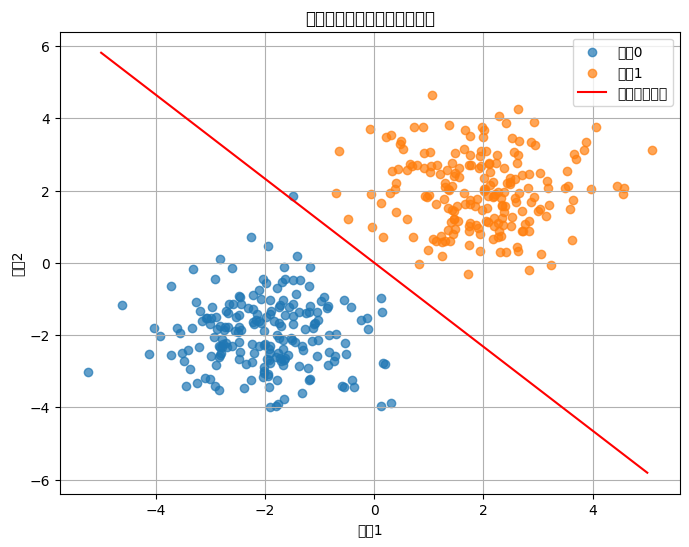

In [5]:
# 6.2 编程题：逻辑回归分类
import numpy as np
import matplotlib.pyplot as plt

# -------------------------- 1. 生成线性可分数据集 --------------------------
np.random.seed(42)  # 固定随机种子，结果可复现
# 类别0：200个二维样本
class0 = np.random.randn(200, 2) + np.array([-2, -2])
# 类别1：200个二维样本
class1 = np.random.randn(200, 2) + np.array([2, 2])
# 合并训练数据与标签
X_train = np.vstack((class0, class1))
y_train = np.hstack((np.zeros(200), np.ones(200))).reshape(-1, 1)

# -------------------------- 2. 定义sigmoid与二元交叉熵损失 --------------------------
def sigmoid(z):
    # 数值稳定版sigmoid，防止溢出
    return 1 / (1 + np.exp(-np.clip(z, -50, 50)))

def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8  # 避免log(0)报错
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

# -------------------------- 3. 梯度下降训练参数w、b --------------------------
# 初始化权重与偏置
w = np.zeros((2, 1))
b = 0
lr = 0.1  # 题目指定学习率
iterations = 1000  # 题目指定迭代次数
loss_history = []

# 梯度下降迭代
for i in range(iterations):
    # 前向传播
    z = X_train @ w + b
    y_pred = sigmoid(z)
    # 计算损失
    loss = binary_cross_entropy(y_train, y_pred)
    loss_history.append(loss)
    # 手动计算梯度
    dw = (X_train.T @ (y_pred - y_train)) / len(X_train)
    db = np.mean(y_pred - y_train)
    # 参数更新
    w -= lr * dw
    b -= lr * db

# -------------------------- 4. 生成测试集+计算准确率+绘制决策边界 --------------------------
# 新生成100个测试样本
test_class0 = np.random.randn(50, 2) + np.array([-2, -2])
test_class1 = np.random.randn(50, 2) + np.array([2, 2])
X_test = np.vstack((test_class0, test_class1))
y_test = np.hstack((np.zeros(50), np.ones(50))).reshape(-1, 1)

# 测试集预测与准确率
test_pred_prob = sigmoid(X_test @ w + b)
test_pred = (test_pred_prob >= 0.5).astype(int)
acc = np.mean(test_pred == y_test)

print("训练完成！最终参数 w=%s, b=%.4f" % (w.ravel(), b))
print("测试集（100个新样本）分类准确率：%.2f%%" % (acc*100))

# 绘制数据点与决策边界
plt.figure(figsize=(8,6))
# 原始训练数据散点
plt.scatter(class0[:,0], class0[:,1], label="类别0", alpha=0.7)
plt.scatter(class1[:,0], class1[:,1], label="类别1", alpha=0.7)
# 计算并绘制决策边界 w1*x1 + w2*x2 + b = 0
x_bound = np.linspace(-5, 5, 100)
y_bound = -(w[0,0]*x_bound + b) / w[1,0]
plt.plot(x_bound, y_bound, "r-", label="模型决策边界")

plt.xlabel("特征1")
plt.ylabel("特征2")
plt.legend()
plt.title("逻辑回归分类结果与决策边界")
plt.grid(True)
plt.show()